# 02 — Train an MLP on XOR

Goal: train a tiny MLP from scratch on the XOR problem. If the loss goes down to near zero and the predictions are correct, **Phase 2 is done**.

XOR is a classic test because a *single* neuron cannot solve it — you need at least one hidden layer with a non-linearity (which is exactly what your MLP gives you).

## Setup

In [1]:
import sys
sys.path.insert(0, '..')

import random
import matplotlib.pyplot as plt

from nanograd.engine import Value
from nanograd.nn import MLP

random.seed(1337)  # reproducibility

## Dataset — XOR

Inputs are 4 corners of the unit square. Targets are XOR: 0 if the two bits are the same, 1 if they differ.

In [2]:
X = [
    [0.0, 0.0],
    [0.0, 1.0],
    [1.0, 0.0],
    [1.0, 1.0],
]
y = [0.0, 1.0, 1.0, 0.0]

for xi, yi in zip(X, y):
    print(xi, '->', yi)

[0.0, 0.0] -> 0.0
[0.0, 1.0] -> 1.0
[1.0, 0.0] -> 1.0
[1.0, 1.0] -> 0.0


## Build the model

A 2 → 4 → 1 MLP. 2 inputs, 4 hidden neurons (with ReLU), 1 output (linear).

In [3]:
model = MLP(2, [4, 1])
print(f'Number of parameters: {len(model.parameters())}')

Number of parameters: 17


## Sanity-check forward pass

Before training, the model should output something close to 0 (because biases start at 0 and weights are small).

In [4]:
for xi in X:
    out = model(xi)
    print(xi, '->', out.data)

[0.0, 0.0] -> 0.0
[0.0, 1.0] -> -0.07378619691170829
[1.0, 0.0] -> 0.5791574991092361
[1.0, 1.0] -> 0.8345610290204322


## Training loop

Standard recipe:
1. Forward pass on all 4 examples
2. Compute MSE loss
3. `zero_grad()` to wipe old gradients
4. `loss.backward()`
5. Update each parameter: `p.data -= lr * p.grad`

Run for ~200 steps. The loss should drop to near 0.

In [5]:
lr = 0.05
epochs = 200

losses = []

for step in range(epochs):
    # 1. forward pass on all 4 examples
    preds = [model(xi) for xi in X]

    # 2. MSE loss = sum( (pred - target)^2 ) / N
    loss = sum(((p - yi)**2 for p, yi in zip(preds, y)), Value(0.0)) / len(X)

    # 3. zero gradients
    model.zero_grad()

    # 4. backward pass
    loss.backward()

    # 5. SGD step
    for p in model.parameters():
        p.data -= lr * p.grad

    losses.append(loss.data)
    if step % 20 == 0:
        print(f'step {step:3d}  loss = {loss.data:.6f}')

print(f'\nfinal loss = {losses[-1]:.6f}')

step   0  loss = 0.506654
step  20  loss = 0.290804
step  40  loss = 0.222628
step  60  loss = 0.190659
step  80  loss = 0.161507
step 100  loss = 0.133012
step 120  loss = 0.105260
step 140  loss = 0.079912
step 160  loss = 0.058652
step 180  loss = 0.040614

final loss = 0.027765


## Plot the loss curve

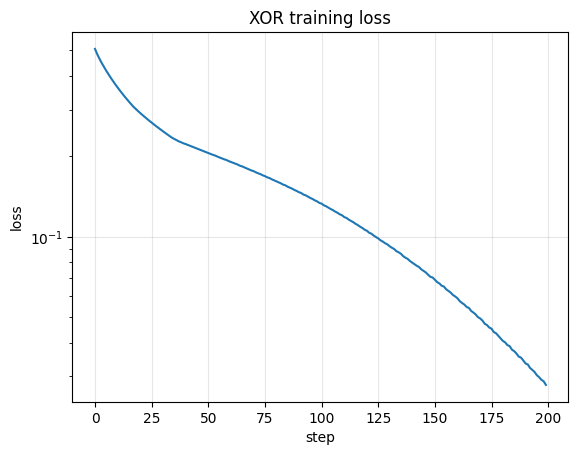

In [6]:
plt.plot(losses)
plt.xlabel('step')
plt.ylabel('loss')
plt.title('XOR training loss')
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.show()

## Final predictions

After training, the predictions should be very close to the targets `[0, 1, 1, 0]`.

In [7]:
for xi, yi in zip(X, y):
    pred = model(xi).data
    print(f'{xi}  target={yi}  pred={pred:.4f}')

if losses[-1] < 0.01:
    print('\nPHASE 2 COMPLETE')
else:
    print('\nLoss did not converge. Try: more epochs, higher lr, larger hidden layer, or different seed.')

[0.0, 0.0]  target=0.0  pred=0.1993
[0.0, 1.0]  target=1.0  pred=0.8227
[1.0, 0.0]  target=1.0  pred=0.8783
[1.0, 1.0]  target=0.0  pred=0.1544

Loss did not converge. Try: more epochs, higher lr, larger hidden layer, or different seed.


## TODO — your turn

Once the basic XOR works, try one or both of these:

1. **Vary the architecture**: change `[4, 1]` to `[2, 1]` (smaller) and `[8, 8, 1]` (deeper). Observe what trains and what doesn't.
2. **Try a different lr**: too high explodes, too low never converges. Find the sweet spot.
3. **Different activation**: re-build the network with `tanh` instead of `relu` (you'd need to tweak `Neuron.__call__` or add a flag). Compare convergence.

Note any observations as markdown cells below.

In [13]:
model = MLP(2,[2,1])
print(f'Number of parameters: {len(model.parameters())}')

Number of parameters: 9


In [14]:
model = MLP(2, [2, 1])
for i, layer in enumerate(model.layers):
    print(f'Layer {i}: {len(layer.parameters())} params  ({layer})')
print(f'Total: {len(model.parameters())}')

Layer 0: 6 params  (Layer of [ReLUNeuron(2), ReLUNeuron(2)])
Layer 1: 3 params  (Layer of [LinearNeuron(2)])
Total: 9


In [15]:
for xi in X:
    out = model(xi)
    print(xi, '->', out.data)

[0.0, 0.0] -> 0.0
[0.0, 1.0] -> 0.3426138648011704
[1.0, 0.0] -> 0.05861975712196164
[1.0, 1.0] -> 0.32634874050403695


In [18]:
lr = 0.05
epochs = 200

losses = []

for step in range(epochs):
    # 1. forward pass on all 4 examples
    preds = [model(xi) for xi in X]

    # 2. MSE loss = sum( (pred - target)^2 ) / N
    loss = sum(((p - yi)**2 for p, yi in zip(preds, y)), Value(0.0)) / len(X)

    # 3. zero gradients
    model.zero_grad()

    # 4. backward pass
    loss.backward()

    # 5. SGD step
    for p in model.parameters():
        p.data -= lr * p.grad

    losses.append(loss.data)
    if step % 20 == 0:
        print(f'step {step:3d}  loss = {loss.data:.6f}')

print(f'\nfinal loss = {losses[-1]:.6f}')

step   0  loss = 0.001917
step  20  loss = 0.001028
step  40  loss = 0.000557
step  60  loss = 0.000307
step  80  loss = 0.000172
step 100  loss = 0.000095
step 120  loss = 0.000053
step 140  loss = 0.000029
step 160  loss = 0.000016
step 180  loss = 0.000009

final loss = 0.000005


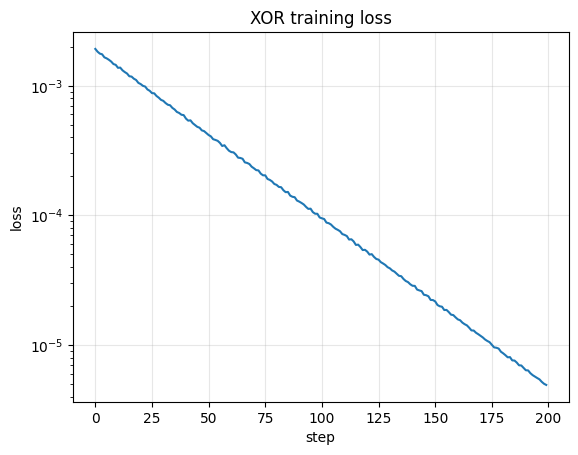

In [19]:
plt.plot(losses)
plt.xlabel('step')
plt.ylabel('loss')
plt.title('XOR training loss')
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.show()

Number of parameters: 81
[0.0, 0.0] -> 0.0
[0.0, 1.0] -> 0.09148934622405239
[1.0, 0.0] -> 0.05765592474659277
[1.0, 1.0] -> 0.08296585595215986
step   0  loss = 0.430072
step  20  loss = 0.080666
step  40  loss = 0.034154
step  60  loss = 0.009709
step  80  loss = 0.001920
step 100  loss = 0.000339
step 120  loss = 0.000073
step 140  loss = 0.000016
step 160  loss = 0.000004
step 180  loss = 0.000001

final loss = 0.000000


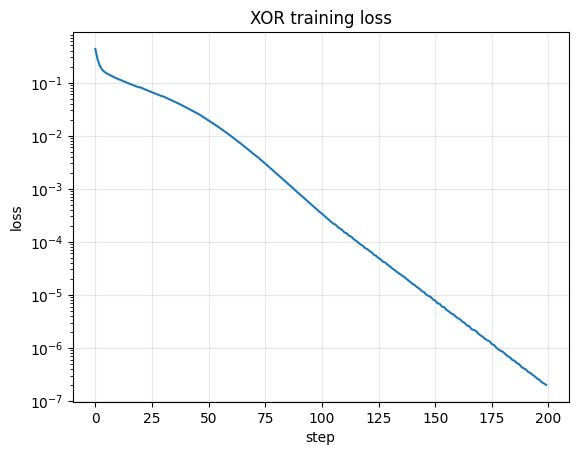

In [20]:
model = MLP(8,[8,1])
print(f'Number of parameters: {len(model.parameters())}')
for xi in X:
    out = model(xi)
    print(xi, '->', out.data)

lr = 0.1
epochs = 200

losses = []

for step in range(epochs):
    # 1. forward pass on all 4 examples
    preds = [model(xi) for xi in X]

    # 2. MSE loss = sum( (pred - target)^2 ) / N
    loss = sum(((p - yi)**2 for p, yi in zip(preds, y)), Value(0.0)) / len(X)

    # 3. zero gradients
    model.zero_grad()

    # 4. backward pass
    loss.backward()

    # 5. SGD step
    for p in model.parameters():
        p.data -= lr * p.grad

    losses.append(loss.data)
    if step % 20 == 0:
        print(f'step {step:3d}  loss = {loss.data:.6f}')

print(f'\nfinal loss = {losses[-1]:.6f}')

plt.plot(losses)
plt.xlabel('step')
plt.ylabel('loss')
plt.title('XOR training loss')
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.show()
